In [1]:
# Import libraries

import sys
import random
import warnings

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import mlxtend

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

warnings.filterwarnings("ignore")

In [2]:
# Library version check

print('Python     :', sys.version.split()[0])
print('pandas     :', pd.__version__)
print('numpy      :', np.__version__)
print('matplotlib :', matplotlib.__version__)
print('seaborn    :', sns.__version__)
print('mlxtend    :', mlxtend.__version__)

Python     : 3.11.15
pandas     : 3.0.2
numpy      : 2.4.4
matplotlib : 3.10.9
seaborn    : 0.13.2
mlxtend    : 0.24.0


In [5]:
# Fix the random seed so the same dataset is created every time
random.seed(85)
np.random.seed(85)
# Define all possible grocery items
all_items = [
    'Milk', 'Cereal', 'Bread', 'Peanut Butter', 'Jam',
    'Eggs', 'Bacon', 'Cheese', 'Coffee', 'Creamer',
    'Rice', 'Beans', 'Chicken', 'Lettuce', 'Tomato',
    'Pasta', 'Pasta Sauce', 'Apple', 'Banana', 'Yogurt'
]
# Define realistic grocery item pairs that customers often buy together
common_pairs = [
    ('Milk', 'Cereal'),
    ('Bread', 'Peanut Butter'),
    ('Peanut Butter', 'Jam'),
    ('Eggs', 'Bacon'),
    ('Coffee', 'Creamer'),
    ('Rice', 'Beans'),
    ('Chicken', 'Rice'),
    ('Lettuce', 'Tomato'),
    ('Pasta', 'Pasta Sauce'),
    ('Banana', 'Yogurt')
]
# Extra items customers may randomly add to their basket
extra_items = [
    'Apple', 'Banana', 'Cheese', 'Yogurt', 'Tomato',
    'Lettuce', 'Coffee', 'Creamer', 'Beans', 'Pasta'
]
# Function to generate one grocery shopping basket
def create_basket():
    basket = set()
    basket_size = random.randint(3, 8)
    # Select 1 to 3 common item pairs
    selected_pairs = random.sample(common_pairs, k=random.randint(1, 3))
    for first_item, second_item in selected_pairs:
        basket.add(first_item)
        basket.add(second_item)
    # Add random extra items until the basket reaches the selected size
    while len(basket) < basket_size:
        basket.add(random.choice(extra_items))
    return list(basket)
# Generate 1000 grocery transactions
transactions = [create_basket() for _ in range(1000)]
print("Dataset generated successfully!")
print(f"Total transactions : {len(transactions)}")
print(f"Total unique items : {len(all_items)}")
print(f"Min basket size    : {min(len(t) for t in transactions)} items")
print(f"Max basket size    : {max(len(t) for t in transactions)} items")
print(f"Avg basket size    : {sum(len(t) for t in transactions) / len(transactions):.2f} items")

Dataset generated successfully!
Total transactions : 1000
Total unique items : 20
Min basket size    : 3 items
Max basket size    : 8 items
Avg basket size    : 5.85 items


In [11]:
transaction_table = pd.DataFrame({
    'Transaction_ID': [f'TXN_{i+1:04d}' for i in range(len(transactions))],
    'Items_Purchased': [', '.join(sorted(t)) for t in transactions],
    'Total_Items': [len(t) for t in transactions]
})

transaction_table.head()

,Transaction_ID,Items_Purchased,Total_Items
0,TXN_0001,"Banana, Beans, Bread, Peanut Butter, Rice, Yogurt",6
1,TXN_0002,"Lettuce, Pasta, Tomato, Yogurt",4
2,TXN_0003,"Apple, Banana, Beans, Coffee, Creamer, Pasta, ...",8
3,TXN_0004,"Banana, Lettuce, Tomato, Yogurt",4
4,TXN_0005,"Bacon, Banana, Eggs, Jam, Peanut Butter, Yogurt",6


In [13]:
# Screenshot 3: First 10 rows of readable transaction dataset

transaction_table = pd.DataFrame({
    'Transaction_ID': [f'TXN_{i+1:04d}' for i in range(len(transactions))],
    'Items_Purchased': [', '.join(sorted(t)) for t in transactions],
    'Total_Items': [len(t) for t in transactions]
})

print("First 10 Transactions:")
transaction_table.head(10)

First 10 Transactions:


,Transaction_ID,Items_Purchased,Total_Items
0,TXN_0001,"Banana, Beans, Bread, Peanut Butter, Rice, Yogurt",6
1,TXN_0002,"Lettuce, Pasta, Tomato, Yogurt",4
2,TXN_0003,"Apple, Banana, Beans, Coffee, Creamer, Pasta, ...",8
3,TXN_0004,"Banana, Lettuce, Tomato, Yogurt",4
4,TXN_0005,"Bacon, Banana, Eggs, Jam, Peanut Butter, Yogurt",6
5,TXN_0006,"Apple, Beans, Bread, Jam, Peanut Butter, Rice",6
6,TXN_0007,"Bacon, Eggs, Jam, Pasta, Pasta Sauce, Peanut B...",6
7,TXN_0008,"Beans, Jam, Peanut Butter, Rice",4
8,TXN_0009,"Bread, Chicken, Peanut Butter, Rice",4
9,TXN_0010,"Beans, Cheese, Coffee, Rice",4


In [14]:
# Screenshot 4: Dataset information

print("Transaction table shape:", transaction_table.shape)

print("\nMissing values:")
print(transaction_table.isnull().sum())

print("\nDataset information:")
transaction_table.info()

Transaction table shape: (1000, 3)

Missing values:
Transaction_ID     0
Items_Purchased    0
Total_Items        0
dtype: int64

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Transaction_ID   1000 non-null   str  
 1   Items_Purchased  1000 non-null   str  
 2   Total_Items      1000 non-null   int64
dtypes: int64(1), str(2)
memory usage: 23.6 KB


In [16]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df = pd.DataFrame(te_array, columns=te.columns_)

df.head(10)

,Apple,Bacon,Banana,Beans,Bread,Cereal,Cheese,Chicken,Coffee,Creamer,Eggs,Jam,Lettuce,Milk,Pasta,Pasta Sauce,Peanut Butter,Rice,Tomato,Yogurt
0,False,False,True,True,True,False,False,False,False,False,False,False,False,False,False,False,True,True,False,True
1,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,True
2,True,False,True,True,False,False,False,False,True,True,False,False,False,False,True,True,False,False,False,True
3,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,True
4,False,True,True,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,True
5,True,False,False,True,True,False,False,False,False,False,False,True,False,False,False,False,True,True,False,False
6,False,True,False,False,False,False,False,False,False,False,True,True,False,False,True,True,True,False,False,False
7,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,True,False,False
8,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,True,False,False
9,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False


In [21]:
# Figure 7: Frequent itemsets using Apriori Algorithm

from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    df,
    min_support=0.05,
    use_colnames=True
)

# Add support percentage and itemset size
frequent_itemsets['support_percentage'] = frequent_itemsets['support'] * 100
frequent_itemsets['itemset_size'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

# Sort by support value
frequent_itemsets = frequent_itemsets.sort_values(
    by='support',
    ascending=False
)

# Count itemsets by size
single_items = frequent_itemsets[frequent_itemsets['itemset_size'] == 1]
item_pairs = frequent_itemsets[frequent_itemsets['itemset_size'] == 2]
triplets = frequent_itemsets[frequent_itemsets['itemset_size'] == 3]

print("Total frequent itemsets found:", len(frequent_itemsets))
print("Single items found:", len(single_items))
print("Item pairs found:", len(item_pairs))
print("Triplets found:", len(triplets))

print("\nTop 20 Frequent Itemsets:")
frequent_itemsets.head(20)

Total frequent itemsets found: 286
Single items found: 20
Item pairs found: 132
Triplets found: 129

Top 20 Frequent Itemsets:


,support,itemsets,support_percentage,itemset_size
3,0.403,frozenset({Beans}),40.3,1
18,0.401,frozenset({Tomato}),40.1,1
14,0.401,frozenset({Pasta}),40.1,1
19,0.394,frozenset({Yogurt}),39.4,1
12,0.390,frozenset({Lettuce}),39.0,1
17,0.380,frozenset({Rice}),38.0,1
9,0.376,frozenset({Creamer}),37.6,1
8,0.374,frozenset({Coffee}),37.4,1
2,0.366,frozenset({Banana}),36.6,1
16,0.363,frozenset({Peanut Butter}),36.3,1


In [22]:
# Figure 8: Association rules sorted by confidence score

from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.30
)

rules_selected = rules[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
]

rules_selected = rules_selected.sort_values(
    by='confidence',
    ascending=False
)

print("Total association rules generated:", len(rules_selected))

print("\nTop 15 Rules Sorted by Confidence:")
rules_selected.head(15)

Total association rules generated: 547

Top 15 Rules Sorted by Confidence:


,antecedents,consequents,support,confidence,lift
527,"frozenset({Milk, Yogurt})",frozenset({Cereal}),0.052,1.0,5.263158
526,"frozenset({Cereal, Yogurt})",frozenset({Milk}),0.052,1.0,5.263158
503,"frozenset({Bread, Beans})",frozenset({Peanut Butter}),0.054,1.0,2.754821
496,"frozenset({Rice, Bacon})",frozenset({Eggs}),0.054,1.0,4.784689
495,"frozenset({Eggs, Rice})",frozenset({Bacon}),0.054,1.0,4.784689
494,"frozenset({Rice, Bread})",frozenset({Peanut Butter}),0.054,1.0,2.754821
286,"frozenset({Eggs, Coffee})",frozenset({Bacon}),0.065,1.0,4.784689
505,"frozenset({Coffee, Cereal})",frozenset({Milk}),0.054,1.0,5.263158
504,"frozenset({Coffee, Milk})",frozenset({Cereal}),0.054,1.0,5.263158
482,"frozenset({Pasta Sauce, Beans})",frozenset({Pasta}),0.055,1.0,2.493766


In [23]:
# Figure 9: Highest-confidence association rule and business meaning

highest_confidence_rule = rules_selected.iloc[0]

print("=" * 70)
print("HIGHEST CONFIDENCE ASSOCIATION RULE")
print("=" * 70)

print("Rule       :", set(highest_confidence_rule['antecedents']), "-->", set(highest_confidence_rule['consequents']))
print("Support    :", round(highest_confidence_rule['support'], 4), 
      f"({highest_confidence_rule['support'] * 100:.1f}% of 1000 transactions)")
print("Confidence :", round(highest_confidence_rule['confidence'], 4), 
      f"({highest_confidence_rule['confidence'] * 100:.1f}%)")
print("Lift       :", round(highest_confidence_rule['lift'], 4))

print("\nMEANING:")
print("This rule means that when customers buy", list(highest_confidence_rule['antecedents']), 
      "they are very likely to also buy", list(highest_confidence_rule['consequents']), 
      "in the same shopping trip.")
print("The confidence score shows how often the second item is purchased when the first item is already purchased.")
print("The lift value shows whether this relationship is stronger than random chance.")

print("=" * 70)
print("BEST PRACTICAL RULE FOR STORE MANAGER")
print("=" * 70)

print("Best Rule  :", set(highest_confidence_rule['antecedents']), "-->", set(highest_confidence_rule['consequents']))
print("Support    :", round(highest_confidence_rule['support'], 4))
print("Confidence :", round(highest_confidence_rule['confidence'], 4))
print("Lift       :", round(highest_confidence_rule['lift'], 4))

print("\nSTORE MANAGER INTERPRETATION:")
print("A store manager can use this rule to understand which products customers usually buy together.")
print("If the goal is customer convenience, the manager can place these two items close to each other.")
print("If the goal is to increase store exposure, the manager can place them in different aisles so customers walk through more sections of the store.")
print("This can increase the chance that customers notice and buy additional products.")
print("=" * 70)

HIGHEST CONFIDENCE ASSOCIATION RULE
Rule       : {'Milk', 'Yogurt'} --> {'Cereal'}
Support    : 0.052 (5.2% of 1000 transactions)
Confidence : 1.0 (100.0%)
Lift       : 5.2632

MEANING:
This rule means that when customers buy ['Milk', 'Yogurt'] they are very likely to also buy ['Cereal'] in the same shopping trip.
The confidence score shows how often the second item is purchased when the first item is already purchased.
The lift value shows whether this relationship is stronger than random chance.
BEST PRACTICAL RULE FOR STORE MANAGER
Best Rule  : {'Milk', 'Yogurt'} --> {'Cereal'}
Support    : 0.052
Confidence : 1.0
Lift       : 5.2632

STORE MANAGER INTERPRETATION:
A store manager can use this rule to understand which products customers usually buy together.
If the goal is customer convenience, the manager can place these two items close to each other.
If the goal is to increase store exposure, the manager can place them in different aisles so customers walk through more sections of t

In [24]:
# Table 1: Top 6 association rules with business interpretation

rules_readable = rules_selected.copy()

rules_readable['antecedents'] = rules_readable['antecedents'].apply(
    lambda x: ', '.join(list(x))
)

rules_readable['consequents'] = rules_readable['consequents'].apply(
    lambda x: ', '.join(list(x))
)

rules_readable['Rule'] = rules_readable['antecedents'] + ' → ' + rules_readable['consequents']

rules_readable['Business Interpretation'] = rules_readable.apply(
    lambda row: f"When customers buy {row['antecedents']}, they are likely to also buy {row['consequents']}.",
    axis=1
)

top_6_rules = rules_readable[
    ['Rule', 'support', 'confidence', 'lift', 'Business Interpretation']
].head(6)

top_6_rules

,Rule,support,confidence,lift,Business Interpretation
527,"Milk, Yogurt → Cereal",0.052,1.0,5.263158,"When customers buy Milk, Yogurt, they are like..."
526,"Cereal, Yogurt → Milk",0.052,1.0,5.263158,"When customers buy Cereal, Yogurt, they are li..."
503,"Bread, Beans → Peanut Butter",0.054,1.0,2.754821,"When customers buy Bread, Beans, they are like..."
496,"Rice, Bacon → Eggs",0.054,1.0,4.784689,"When customers buy Rice, Bacon, they are likel..."
495,"Eggs, Rice → Bacon",0.054,1.0,4.784689,"When customers buy Eggs, Rice, they are likely..."
494,"Rice, Bread → Peanut Butter",0.054,1.0,2.754821,"When customers buy Rice, Bread, they are likel..."


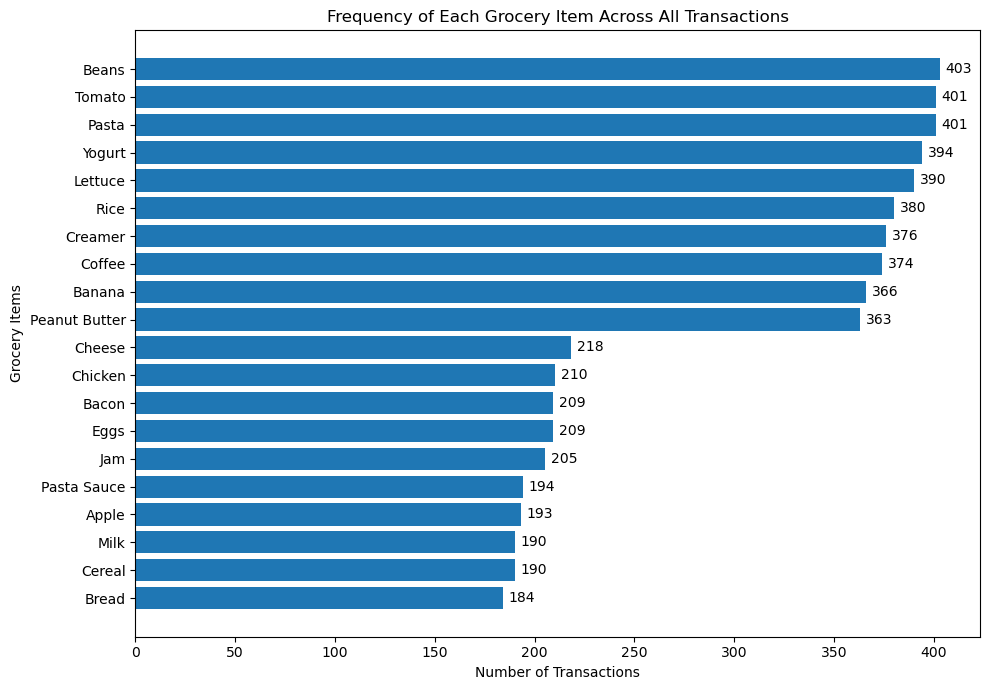

In [ ]:
# Frequency of each grocery item across all transactions

import matplotlib.pyplot as plt

df_binary = df.astype(int)

item_counts = df_binary.sum().sort_values(ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(
    item_counts.index,
    item_counts.values
)

plt.title("Frequency of Each Grocery Item Across All Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Grocery Items")

for index, value in enumerate(item_counts.values):
    plt.text(value + 3, index, str(value), va='center')

plt.tight_layout()
plt.show()

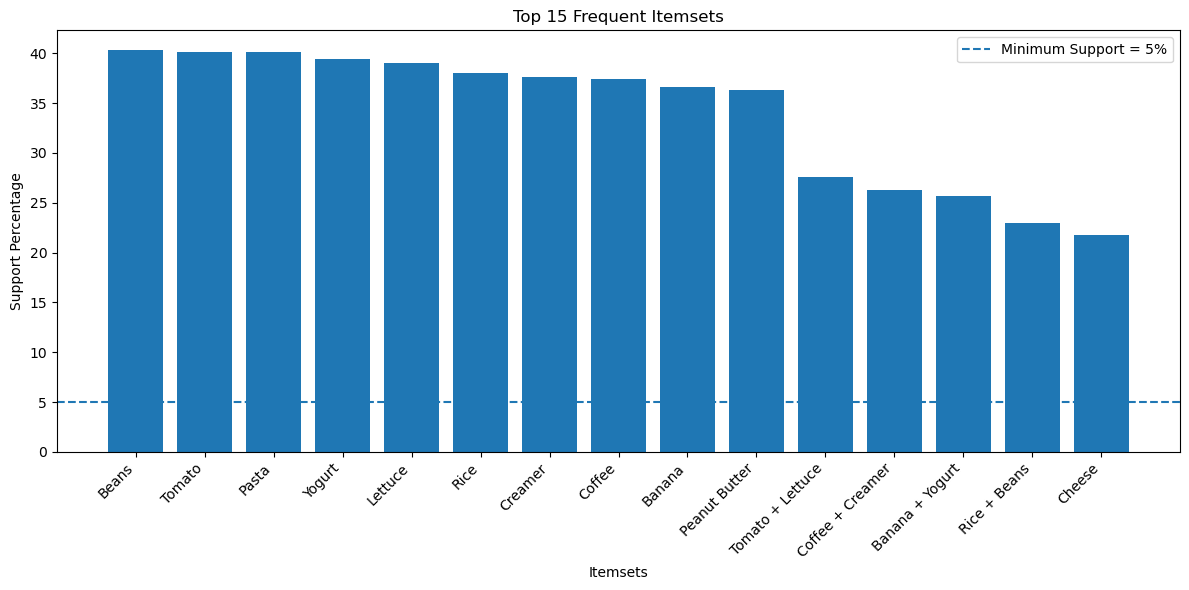

In [26]:
# Top 15 frequent itemsets by support percentage

top_itemsets = frequent_itemsets.head(15).copy()

top_itemsets['itemsets_label'] = top_itemsets['itemsets'].apply(
    lambda x: ' + '.join(list(x))
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_itemsets['itemsets_label'],
    top_itemsets['support_percentage']
)

plt.axhline(
    y=5,
    linestyle='--',
    label='Minimum Support = 5%'
)

plt.title("Top 15 Frequent Itemsets")
plt.xlabel("Itemsets")
plt.ylabel("Support Percentage")
plt.xticks(rotation=45, ha='right')
plt.legend()

plt.tight_layout()
plt.show()

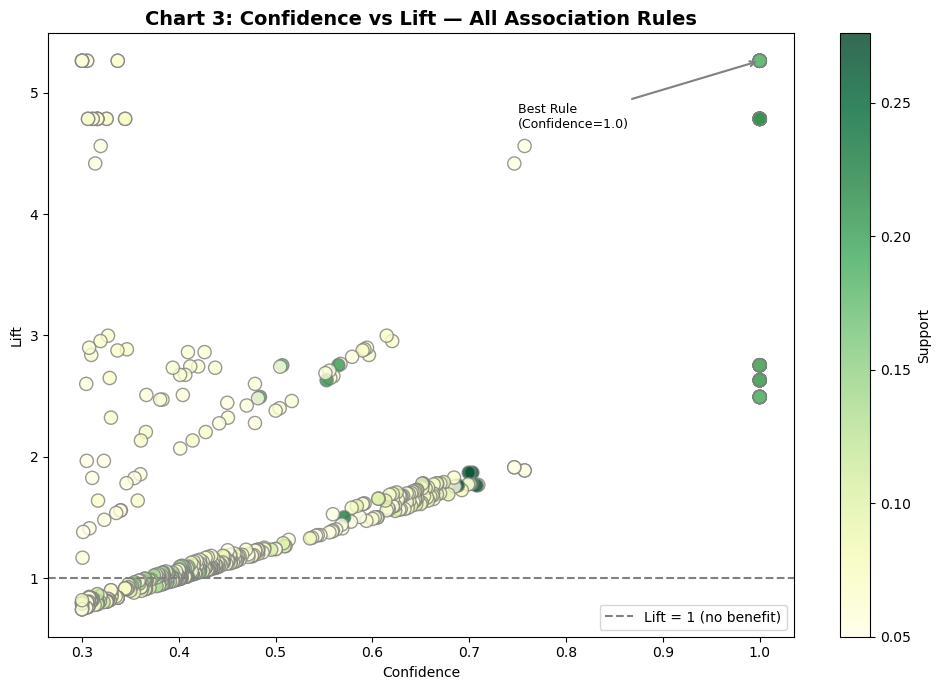

In [ ]:
# Confidence vs Lift Scatter Plot with Best Rule Arrow

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    rules_selected['confidence'],
    rules_selected['lift'],
    c=rules_selected['support'],
    s=90,
    cmap='YlGn',
    alpha=0.8,
    edgecolor='gray'
)

plt.colorbar(scatter, label='Support')

plt.title(
    "Chart 3: Confidence vs Lift — All Association Rules",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Confidence")
plt.ylabel("Lift")

plt.axhline(
    y=1,
    linestyle='--',
    color='gray',
    label='Lift = 1 (no benefit)'
)

# Find the best rule
best_rule = rules_selected.iloc[0]

# Add arrow and label for best rule
plt.annotate(
    "Best Rule\n(Confidence=1.0)",
    xy=(best_rule['confidence'], best_rule['lift']),
    xytext=(best_rule['confidence'] - 0.25, best_rule['lift'] - 0.55),
    arrowprops=dict(
        arrowstyle='->',
        color='gray',
        linewidth=1.5
    ),
    fontsize=9
)

plt.legend()
plt.tight_layout()
plt.show()

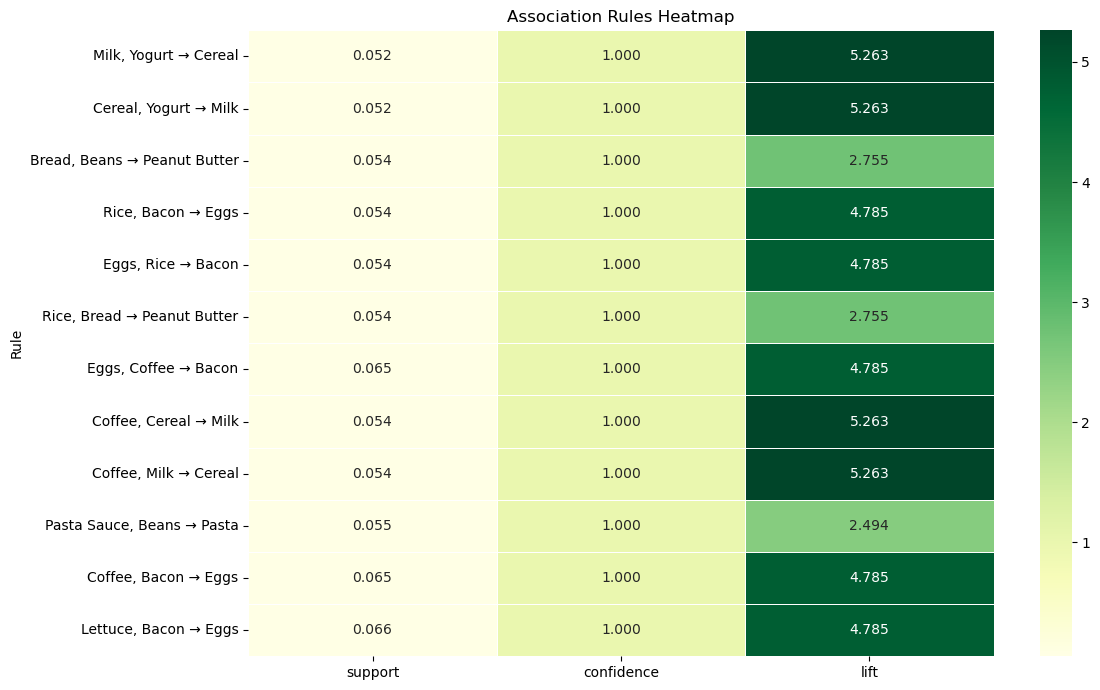

In [29]:
# Association Rules Heatmap

import seaborn as sns

top_rules_heatmap = rules_readable.head(12).copy()

top_rules_heatmap['Rule'] = (
    top_rules_heatmap['antecedents'] + ' → ' + top_rules_heatmap['consequents']
)

heatmap_data = top_rules_heatmap.set_index('Rule')[
    ['support', 'confidence', 'lift']
]

plt.figure(figsize=(12, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.3f',
    cmap='YlGn',
    linewidths=0.5
)

plt.title("Association Rules Heatmap")
plt.tight_layout()
plt.show()

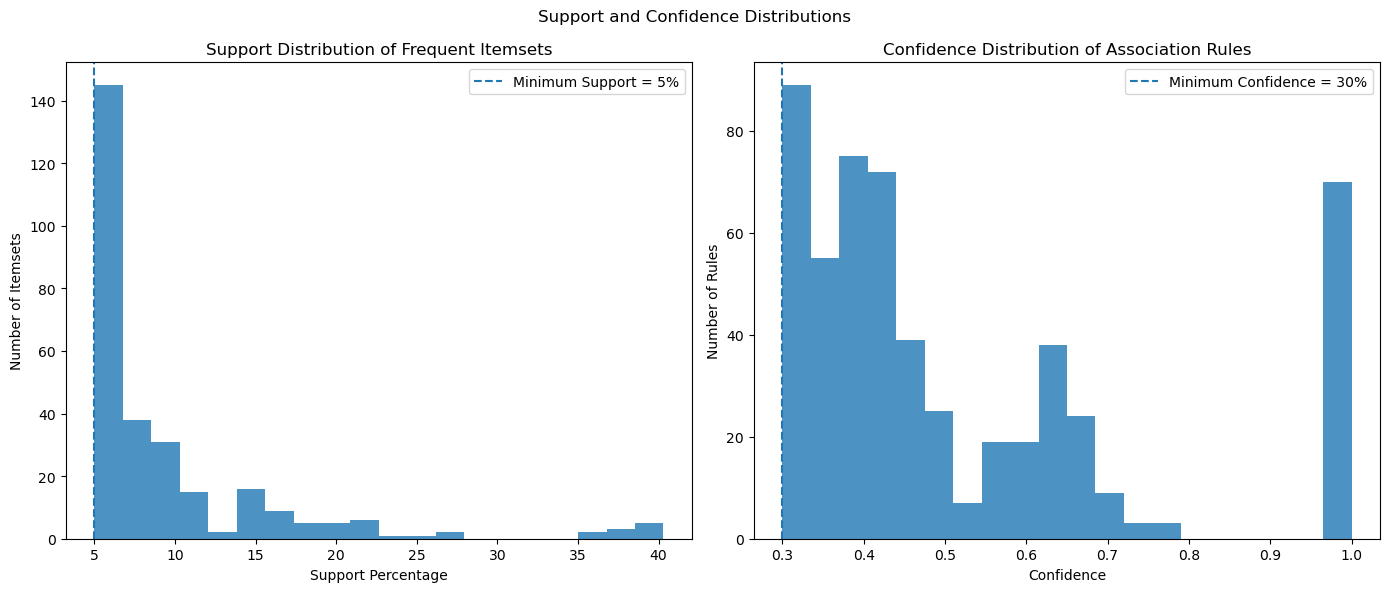

In [30]:
# Support and Confidence Distributions

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Support distribution
axes[0].hist(
    frequent_itemsets['support_percentage'],
    bins=20,
    alpha=0.8
)

axes[0].axvline(
    x=5,
    linestyle='--',
    label='Minimum Support = 5%'
)

axes[0].set_title("Support Distribution of Frequent Itemsets")
axes[0].set_xlabel("Support Percentage")
axes[0].set_ylabel("Number of Itemsets")
axes[0].legend()

# Confidence distribution
axes[1].hist(
    rules_selected['confidence'],
    bins=20,
    alpha=0.8
)

axes[1].axvline(
    x=0.30,
    linestyle='--',
    label='Minimum Confidence = 30%'
)

axes[1].set_title("Confidence Distribution of Association Rules")
axes[1].set_xlabel("Confidence")
axes[1].set_ylabel("Number of Rules")
axes[1].legend()

plt.suptitle("Support and Confidence Distributions")
plt.tight_layout()
plt.show()